# 04 — Predicciones con el MLP seleccionado en validación

Reutiliza exactamente la decisión persistida por 02B (mayor PR-AUC en validación 20%, semilla 42). Este notebook no evalúa ni selecciona modelos.

In [19]:
# ==============================
# Imports
# ==============================

from __future__ import annotations

import json
import warnings
from pathlib import Path
from typing import Tuple

import joblib

# Necesario para poder reconstruir ScaledKNNImputer al cargar
# preprocessing_objects.joblib (ver preprocessing_utils.py).
from preprocessing_utils import ScaledKNNImputer  # noqa: F401
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

OUTPUT_DIR = Path("outputs")
OBJECTS_DIR = OUTPUT_DIR / "objects"
MODELS_DIR = OUTPUT_DIR / "models"
PRED_DIR = OUTPUT_DIR / "predictions"
PRED_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

Device: cpu


## 1. Carga de producción y objetos entrenados

Este notebook requiere haber ejecutado antes los notebooks 01 y 02.

In [20]:
import importlib
import utils.heterogeneous_mlp as heterogeneous_utils
heterogeneous_utils = importlib.reload(heterogeneous_utils)
load_selection_manifest = heterogeneous_utils.load_selection_manifest
load_keras_model_from_manifest = heterogeneous_utils.load_keras_model_from_manifest
predict_selected_proba = heterogeneous_utils.predict_selected_proba
verify_runtime_contract = heterogeneous_utils.verify_runtime_contract
required_files=[OUTPUT_DIR/'preprocessed_prod.csv',MODELS_DIR/'mlp_selection_manifest.json']
for path in required_files:
    if not path.exists(): raise FileNotFoundError(f'Falta {path}. Ejecuta 01, 02 y 02B.')
prod_df=pd.read_csv(OUTPUT_DIR/'preprocessed_prod.csv'); manifest=load_selection_manifest()
TARGET='SeriousDlqin2yrs'; FEATURES=manifest['preprocessing_spec']['features']
selected_model=load_keras_model_from_manifest(manifest); verify_runtime_contract(selected_model,prod_df,manifest)
MODEL_LOAD_STRATEGY=('reconstrucción modular + carga de pesos' if manifest['selected_model']['name']=='heterogeneous_mlp'
                     else 'deserialización Keras estándar')
model_metadata={'scenarios':manifest['scenarios'],'selected_models':{s:{'model_family':'KerasMLP',
 'model_file':manifest['selected_model']['model_file'],'threshold':manifest['thresholds'][s]} for s in manifest['scenarios']}}
print('Modelo fijado por 02B:',manifest['selected_model']['name'])
print('Estrategia de carga:',MODEL_LOAD_STRATEGY)
print('PR-AUC validación:',manifest['validation_scores'],'| criterio:',manifest['selection_rule'])

Modelo fijado por 02B: heterogeneous_mlp
Estrategia de carga: reconstrucción modular + carga de pesos
PR-AUC validación: {'baseline_keras': 0.37588281250883, 'heterogeneous_mlp': 0.3980583669131988} | criterio: max validation PR-AUC; ties keep baseline


In [21]:
# Opcional: cargamos el fichero original de producción para mantener exactamente sus columnas.
def find_file(filename: str) -> Path:
    candidates = [
        Path.cwd() / "data" / filename,
        Path.cwd() / filename,
        Path.cwd().parent / "data" / filename,
        Path.cwd().parent / filename,
        Path("/mnt/data") / filename,
    ]
    for c in candidates:
        if c.exists():
            return c
    raise FileNotFoundError(filename)

original_prod_path = find_file("cs_produccion.csv")
original_prod = pd.read_csv(original_prod_path)

print("Producción original:", original_prod.shape)
original_prod.head()

# Comprobación de blindaje: las predicciones se asignan a original_prod POR
# POSICIÓN (fila i de prod_df -> fila i de original_prod). Esto solo es
# correcto si los dos ficheros tienen el mismo número de filas Y el mismo
# orden. El notebook 01 nunca elimina duplicados ni reordena producción
# (solo lo hace en construcción), así que debería cumplirse siempre -- pero
# lo comprobamos explícitamente para no depender de que nadie rompa eso sin
# querer en el futuro.
assert len(original_prod) == len(prod_df), (
    f"Desalineación entre cs_produccion.csv ({len(original_prod)} filas) y "
    f"preprocessed_prod.csv ({len(prod_df)} filas). Las predicciones NO se "
    f"pueden asignar por posición si esto no coincide -- revisa el notebook 01."
)
print("Comprobación de alineación OK: mismo número de filas en producción original y preprocesada.")

Producción original: (45000, 11)
Comprobación de alineación OK: mismo número de filas en producción original y preprocesada.


## 2. Carga modular y contrato

Para el MLP heterogéneo, la arquitectura se reconstruye desde el módulo común y se cargan únicamente los pesos del archivo `.keras`. De este modo, producción no depende de deserializar `Lambda` ni clases personalizadas almacenadas en el artefacto. Para el baseline se mantiene la carga Keras estándar. En ambos casos se verifican la huella del preprocesamiento, las columnas y los nombres de entrada antes de predecir.

In [22]:
def predict_for_scenario(scenario):
    selected=model_metadata['selected_models'][scenario]
    score=predict_selected_proba(selected_model,prod_df[FEATURES],manifest)
    pred=(score>=selected['threshold']).astype(int)
    return score,pred,selected

## 3. Generación de predicciones

Generamos un CSV por escenario.

- En `cost_1_1`, el threshold busca minimizar errores con mismo coste.
- En `cost_1_10`, el threshold/política penaliza mucho más los falsos negativos.

Por tanto, normalmente `cs_produccion2.csv` debería tener más predicciones `1` que `cs_produccion1.csv`, porque el modelo es más conservador.

In [23]:
prediction_details = []

for scenario, params in model_metadata["scenarios"].items():
    print("\nGenerando predicciones para:", scenario)
    score, pred, selected = predict_for_scenario(scenario)

    # Fichero de entrega: misma estructura que producción original, con target relleno.
    output = original_prod.copy()
    output[TARGET] = pred.astype(int)

    output_file = PRED_DIR / params["output_file"]
    output.to_csv(output_file, index=False)

    # Fichero de auditoría con detalle.
    detail = pd.DataFrame({
        "row_id": np.arange(len(pred)),
        "scenario": scenario,
        "model_family": selected["model_family"],
        "model_file": selected["model_file"],
        "threshold": selected["threshold"],
        "score_class_1": score,
        "prediction": pred.astype(int),
    })
    prediction_details.append(detail)

    print("Guardado:", output_file)
    print("Distribución predicciones:")
    display(output[TARGET].value_counts(normalize=False).rename_axis("prediction").reset_index(name="n"))
    display(output[TARGET].value_counts(normalize=True).rename_axis("prediction").reset_index(name="pct"))

prediction_details_df = pd.concat(prediction_details, ignore_index=True)
prediction_details_df.to_csv(PRED_DIR / "production_prediction_details.csv", index=False)

print("Detalle guardado en:", PRED_DIR / "production_prediction_details.csv")


# Exportaciones comparativas de regresión logística entrenada en 02.
# Se mantienen separadas de la selección MLP: no intervienen en la elección
# baseline Keras vs. heterogéneo ni modifican sus thresholds.
logreg_required = [
    OBJECTS_DIR/'final_model_scaler.joblib',
    MODELS_DIR/'final_logistic_regression.joblib',
    MODELS_DIR/'model_metadata.joblib',
]
for path in logreg_required:
    if not path.exists():
        raise FileNotFoundError(f'Falta {path}. Ejecuta el notebook 02 para exportar la regresión logística.')

logreg_scaler = joblib.load(OBJECTS_DIR/'final_model_scaler.joblib')
logreg_model = joblib.load(MODELS_DIR/'final_logistic_regression.joblib')
legacy_metadata = joblib.load(MODELS_DIR/'model_metadata.joblib')
logreg_thresholds = legacy_metadata['logreg_thresholds']
X_prod_logreg = logreg_scaler.transform(prod_df[FEATURES].astype(float))
logreg_score = logreg_model.predict_proba(X_prod_logreg)[:, 1]
logreg_output_files = {
    'cost_1_1':'cs_produccion_logistica1.csv',
    'cost_1_10':'cs_produccion_logistica2.csv',
}
logreg_details=[]
for scenario, output_name in logreg_output_files.items():
    threshold=float(logreg_thresholds[scenario])
    pred=(logreg_score>=threshold).astype(int)
    output=original_prod.copy(); output[TARGET]=pred
    output.to_csv(PRED_DIR/output_name,index=False)
    logreg_details.append(pd.DataFrame({
        'row_id':np.arange(len(pred)),'scenario':scenario,
        'model_family':'LogisticRegression','model_file':'final_logistic_regression.joblib',
        'threshold':threshold,'score_class_1':logreg_score,'prediction':pred,
    }))
    print('Guardado adicional logístico:',PRED_DIR/output_name)
pd.concat(logreg_details,ignore_index=True).to_csv(
    PRED_DIR/'production_prediction_details_logistic.csv',index=False
)



Generando predicciones para: cost_1_1
Guardado: outputs\predictions\cs_produccion1.csv
Distribución predicciones:


,prediction,n
0,0,44090
1,1,910


,prediction,pct
0,0,0.9798
1,1,0.0202



Generando predicciones para: cost_1_10
Guardado: outputs\predictions\cs_produccion2.csv
Distribución predicciones:


,prediction,n
0,0,35176
1,1,9824


,prediction,pct
0,0,0.7817
1,1,0.2183


Detalle guardado en: outputs\predictions\production_prediction_details.csv
Guardado adicional logístico: outputs\predictions\cs_produccion_logistica1.csv
Guardado adicional logístico: outputs\predictions\cs_produccion_logistica2.csv


In [24]:
# Comprobaciones de formato de los dos ficheros generados por el modelo seleccionado.
for scenario, params in model_metadata['scenarios'].items():
    path = PRED_DIR / params['output_file']
    df_check = pd.read_csv(path)
    assert df_check.shape[0] == original_prod.shape[0], 'El número de filas debe coincidir con producción.'
    assert list(df_check.columns) == list(original_prod.columns), 'Las columnas deben coincidir con producción original.'
    assert df_check[TARGET].isin([0, 1]).all(), 'El target predicho debe ser binario 0/1.'
    print(path.name, 'OK', df_check.shape)

for output_name in logreg_output_files.values():
    path=PRED_DIR/output_name
    df_check=pd.read_csv(path)
    assert df_check.shape[0]==original_prod.shape[0]
    assert list(df_check.columns)==list(original_prod.columns)
    assert df_check[TARGET].isin([0,1]).all()
    print(path.name,'OK',df_check.shape)

cs_produccion1.csv OK (45000, 11)
cs_produccion2.csv OK (45000, 11)
cs_produccion_logistica1.csv OK (45000, 11)
cs_produccion_logistica2.csv OK (45000, 11)


## 4. Comparación entre escenarios

La comparación siguiente permite verificar que el segundo escenario cambia la política de decisión. Si `FN=10`, se espera que el modelo sea más sensible a detectar la clase 1.

In [25]:
comparison = prediction_details_df.pivot(index="row_id", columns="scenario", values="prediction").reset_index()
scenario_cols = [c for c in comparison.columns if c != "row_id"]

if set(["cost_1_1", "cost_1_10"]).issubset(comparison.columns):
    comparison["changed"] = comparison["cost_1_1"] != comparison["cost_1_10"]
    print("Filas con distinta predicción entre escenarios:", comparison["changed"].sum())
    print("Porcentaje:", 100 * comparison["changed"].mean())

    # Comprobamos explícitamente la hipótesis del enunciado de esta sección:
    # con FN=10, el modelo debería ser más conservador y predecir más 1
    # (denegaciones) que con FP=FN=1. Antes esto solo se podía ver "a ojo"
    # mirando la tabla; ahora queda verificado con un mensaje claro.
    rate_1_1 = comparison["cost_1_1"].mean()
    rate_1_10 = comparison["cost_1_10"].mean()
    print(f"\nTasa de predicción 1 en cost_1_1: {rate_1_1:.4f}")
    print(f"Tasa de predicción 1 en cost_1_10: {rate_1_10:.4f}")

    if rate_1_10 >= rate_1_1:
        print("OK: cost_1_10 predice 1 (deniega) con más frecuencia que cost_1_1, como se esperaba.")
    else:
        print(
            "AVISO: cost_1_10 predice 1 con MENOS frecuencia que cost_1_1. "
            "Esto contradice la hipótesis de la sección 3 -- revisar thresholds/modelos seleccionados."
        )

comparison.head()

Filas con distinta predicción entre escenarios: 8914
Porcentaje: 19.80888888888889

Tasa de predicción 1 en cost_1_1: 0.0202
Tasa de predicción 1 en cost_1_10: 0.2183
OK: cost_1_10 predice 1 (deniega) con más frecuencia que cost_1_1, como se esperaba.


scenario,row_id,cost_1_1,cost_1_10,changed
0,0,0,1,True
1,1,0,1,True
2,2,0,0,False
3,3,0,0,False
4,4,0,0,False


In [26]:
# Resumen de scores por escenario.
score_summary = prediction_details_df.groupby("scenario").agg(
    n=("prediction", "size"),
    predicted_1=("prediction", "sum"),
    predicted_1_rate=("prediction", "mean"),
    score_mean=("score_class_1", "mean"),
    score_p50=("score_class_1", "median"),
    score_p90=("score_class_1", lambda s: s.quantile(0.90)),
    score_p99=("score_class_1", lambda s: s.quantile(0.99)),
).reset_index()

score_summary

,scenario,n,predicted_1,predicted_1_rate,score_mean,score_p50,score_p90,score_p99
0,cost_1_1,45000,910,0.0202,0.3145,0.2125,0.7250,0.9412
1,cost_1_10,45000,9824,0.2183,0.3145,0.2125,0.7250,0.9412


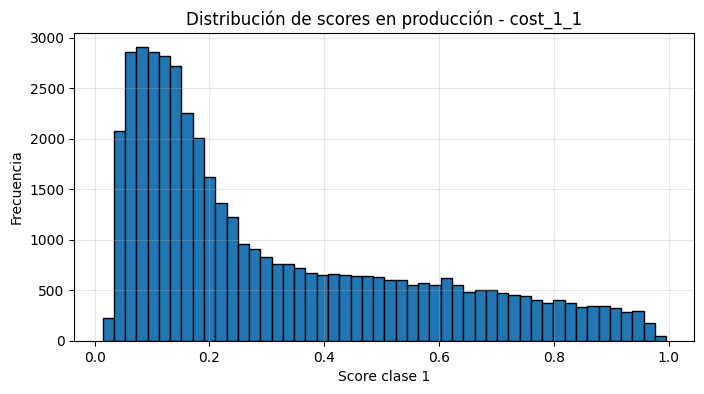

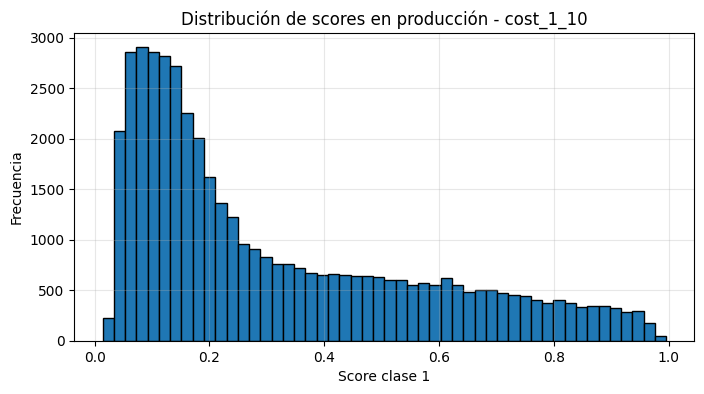

In [27]:
# Histograma de scores por escenario.
for scenario in prediction_details_df["scenario"].unique():
    temp = prediction_details_df[prediction_details_df["scenario"] == scenario]
    plt.figure(figsize=(8, 4))
    plt.hist(temp["score_class_1"], bins=50, edgecolor="black")
    plt.title(f"Distribución de scores en producción - {scenario}")
    plt.xlabel("Score clase 1")
    plt.ylabel("Frecuencia")
    plt.grid(alpha=0.3)
    plt.show()

## 5. Ficheros finales

Los ficheros generados con el único modelo seleccionado en validación son:

- `outputs/predictions/cs_produccion1.csv`
- `outputs/predictions/cs_produccion2.csv`
- `outputs/predictions/production_prediction_details.csv`

Como comparación adicional de 02 también se conservan:

- `outputs/predictions/cs_produccion_logistica1.csv`
- `outputs/predictions/cs_produccion_logistica2.csv`
- `outputs/predictions/production_prediction_details_logistic.csv`

Estas exportaciones no participan en la selección entre los dos MLP; reutilizan el modelo, scaler y thresholds logísticos guardados por 02.